In [180]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import pandas as pd

In [181]:
def get_alamode_phband(alamode_bands: str):
    """
    Return: k-axis and eigenvalues in cm^-1
    """
    data = np.loadtxt(alamode_bands, skiprows=3)
    return data

In [182]:
# alamode_bands: str = "../alamode_phonons/qe_finite_diff/zno222NA3.bands"
alamode_bands = "../alamode_phonons/qe_finite_diff/zno222NA3_GKMGAHK.bands"

ph_data = get_alamode_phband(alamode_bands=alamode_bands)

q = ph_data[:, 0]
freq = ph_data[:, 1:] # cm^-1

In [183]:
def get_brillouin(alamode_bands: str):
    with open(alamode_bands) as f:
        high_symmetry_labels: str = f.readline().strip()
        high_symmetry_points: str = f.readline().strip()

    xticks: list[float] = [float(x) for x in high_symmetry_points.lstrip("#").split()]
    labels: list[str] = high_symmetry_labels.lstrip("#").split()

    xtick_labels = []
    for lab in labels:
        if lab == "G":
            xtick_labels.append(r"$\Gamma$")
        else:
            xtick_labels.append(f"{lab}")

    return xticks, xtick_labels

In [184]:
get_brillouin(alamode_bands)

([0.0, 0.693519, 1.040278, 1.640884, 1.964858, 2.658377, 2.982351],
 ['$\\Gamma$', 'K', 'M', '$\\Gamma$', 'A', 'H', 'K'])

In [185]:
def plot_sym_lines(ax, x_coords):
    for x in x_coords:
        ax.axvline(x, c="gray", alpha=0.5, ls="--")
    


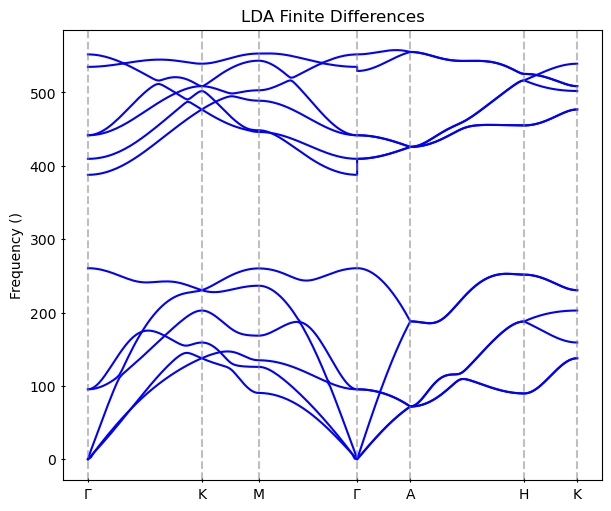

In [186]:
fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
ax.set_title("LDA Finite Differences")
ax.set_ylabel("Frequency ()")
xticks, xlabels = get_brillouin(alamode_bands)
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)


for i in range(freq.shape[1]):
    ax.plot(q, freq[:, i], color="blue")

plot_sym_lines(ax, xticks)

ax.tick_params(axis="both", direction="inout")
plt.show()

In [187]:
def get_qe_phband(qe_data: str):
    """
    Lê o arquivo .gp do Quantum ESPRESSO com frequências em cm^-1
    """
    lines = []
    with open(qe_data) as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                lines.append(line)
    
    data = np.loadtxt(lines)
    q = data[:, 0]
    freqs_invcm = data[:, 1:]

    return q, freqs_invcm

In [188]:
qe_band: str = "../DFT_LDA/02_phonon_DFPT/phononsLDA.dat"
get_qe_phband(qe_band)

(array([0.      , 0.01665 , 0.0333  , 0.04995 , 0.0666  , 0.08325 ,
        0.0999  , 0.11655 , 0.1332  , 0.14985 , 0.1665  , 0.18315 ,
        0.1998  , 0.21645 , 0.2331  , 0.24975 , 0.2664  , 0.28305 ,
        0.2997  , 0.31635 , 0.333   , 0.34965 , 0.3663  , 0.38295 ,
        0.3996  , 0.41625 , 0.4329  , 0.44955 , 0.4662  , 0.48285 ,
        0.4995  , 0.51615 , 0.5328  , 0.54945 , 0.5661  , 0.58275 ,
        0.5994  , 0.61605 , 0.6327  , 0.64935 , 0.666   , 0.674325,
        0.68265 , 0.690975, 0.6993  , 0.707625, 0.71595 , 0.724275,
        0.7326  , 0.740925, 0.74925 , 0.757575, 0.7659  , 0.774225,
        0.78255 , 0.790875, 0.7992  , 0.807525, 0.81585 , 0.824175,
        0.8325  , 0.840825, 0.84915 , 0.857475, 0.8658  , 0.874125,
        0.88245 , 0.890775, 0.8991  , 0.907425, 0.91575 , 0.924075,
        0.9324  , 0.940725, 0.94905 , 0.957375, 0.9657  , 0.974025,
        0.98235 , 0.990675, 0.999001, 1.013434, 1.027868, 1.042302,
        1.056736, 1.071169, 1.085603, 1.100037, 

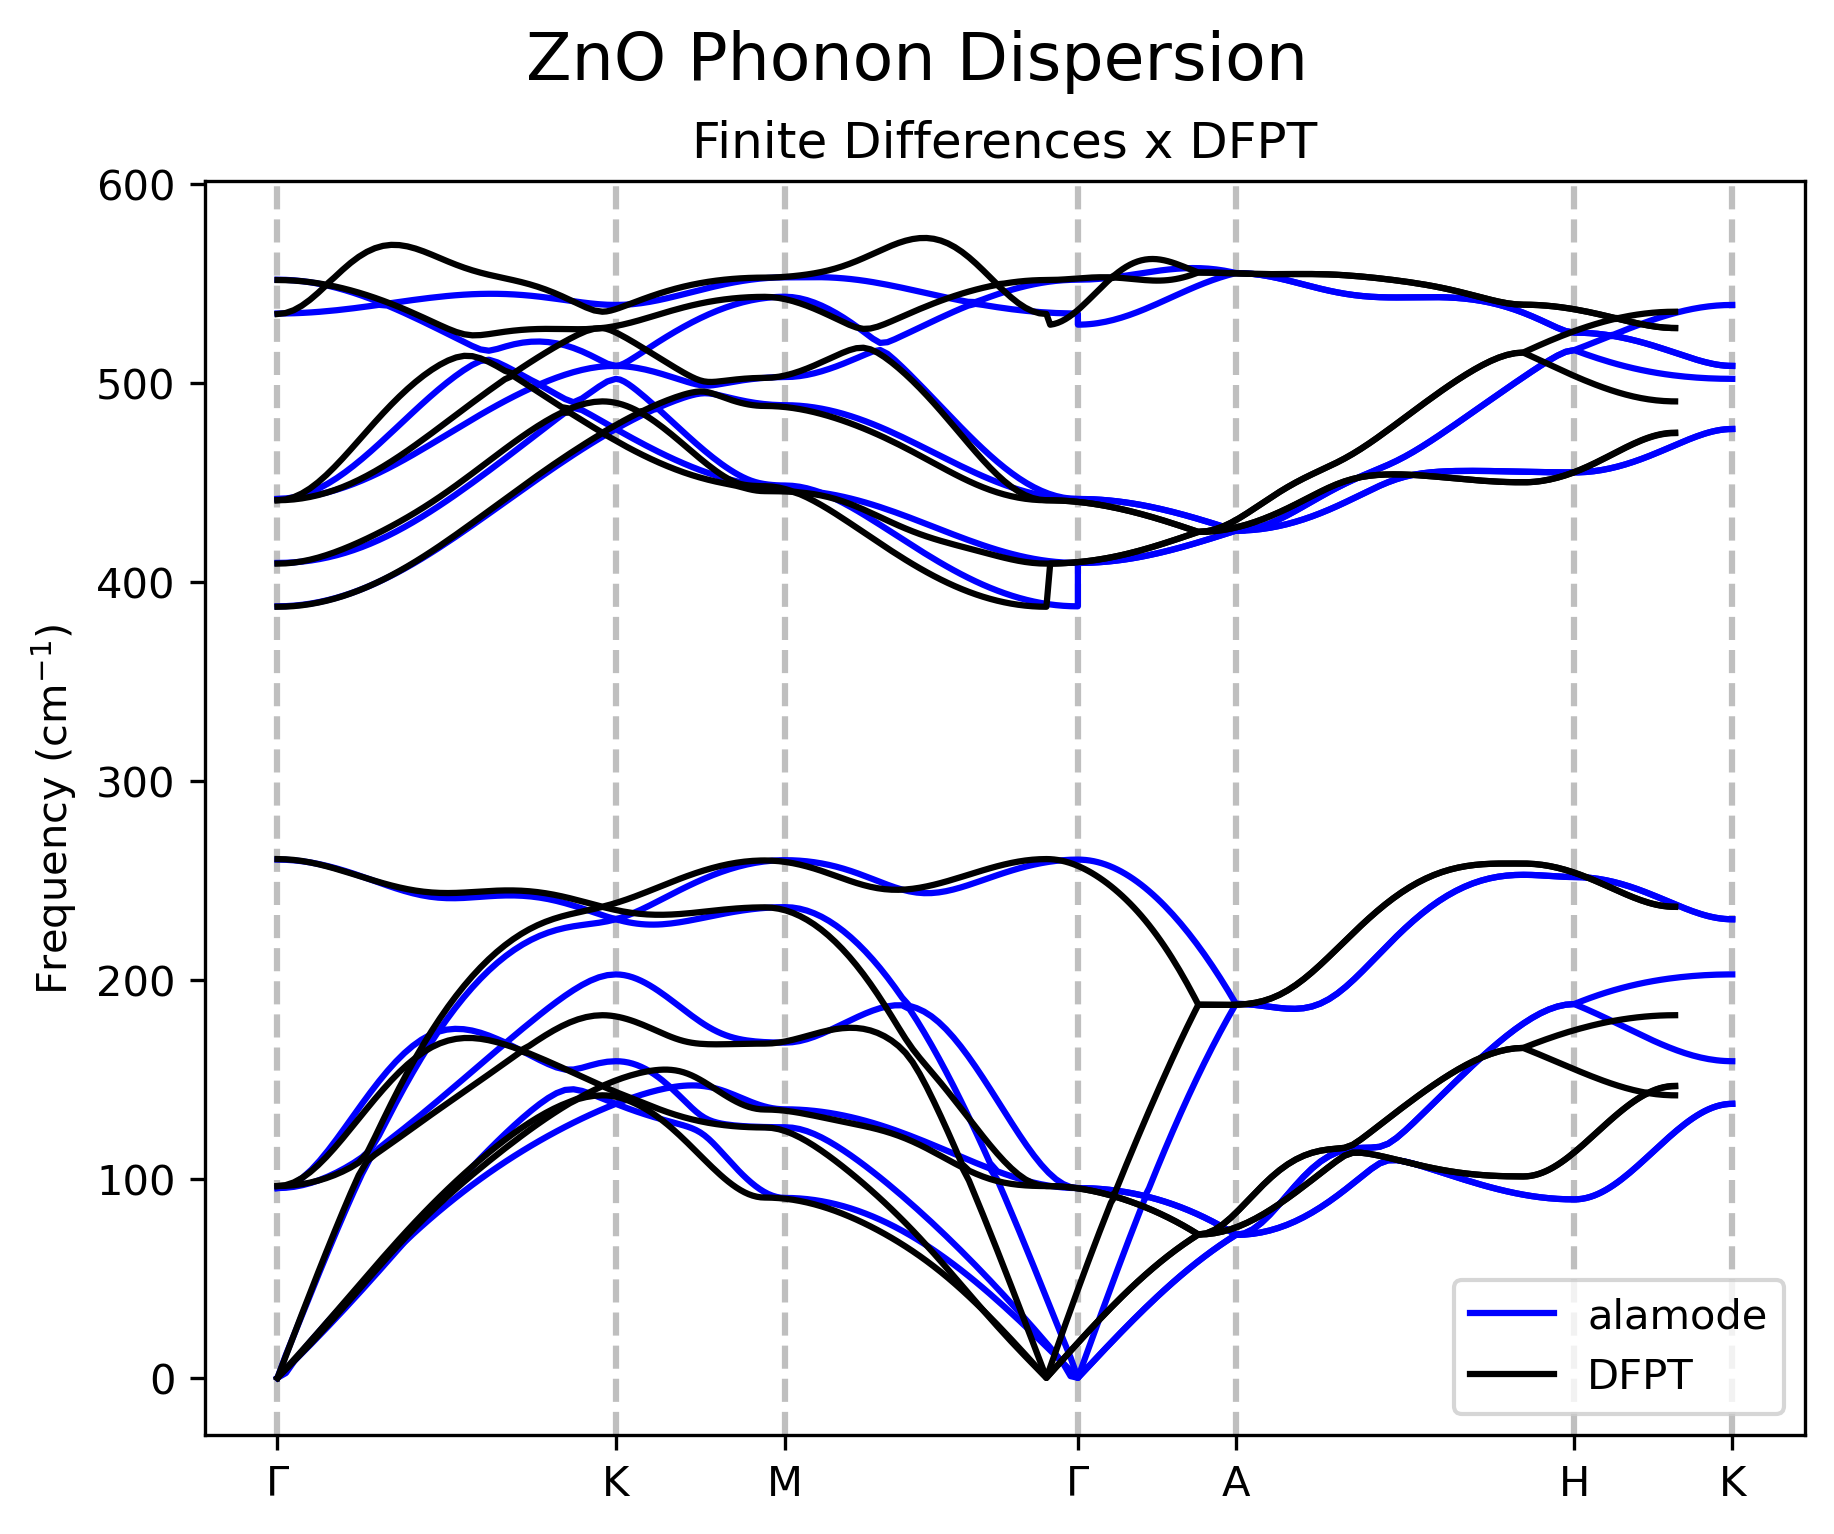

In [189]:
fig, (ax) = plt.subplots(figsize=(6, 5), layout="constrained", dpi=300)
fig.suptitle("ZnO Phonon Dispersion", size=16)
ax.set_title("Finite Differences x DFPT")
ax.set_ylabel(r"Frequency (cm$^{-1}$)")

# --- 
# ALAMODE
alamode_bands = "../alamode_phonons/qe_finite_diff/zno222NA3_GKMGAHK.bands"
ph_data = get_alamode_phband(alamode_bands=alamode_bands)
q = ph_data[:, 0]
freq = ph_data[:, 1:] # cm^-1
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
xticks, xlabels = get_brillouin(alamode_bands)
plot_sym_lines(ax, xticks)
for i in range(freq.shape[1]):
    if i == (freq.shape[1] - 1):
        ax.plot(q, freq[:, i], color="blue", label="alamode")
    else:
        ax.plot(q, freq[:, i], color="blue")

# ---
# Quantum ESPRESSO 
q, freq = get_qe_phband(qe_band)
for i in range(freq.shape[1]):
    if i == (freq.shape[1] - 1):
        ax.plot(q, freq[:, i], color="black", label="DFPT")
    else:
        ax.plot(q, freq[:, i], color="black")

ax.legend()
plt.show()

Em outras palavras: não parece mais erro de caminho, e sim diferença entre os dois conjuntos de IFCs / tratamento físico-numérico.

<h3> Zona de Brillouin </h3>



| | |
|---|---|
| 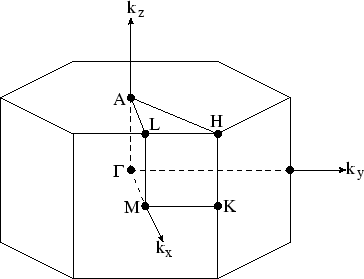 | 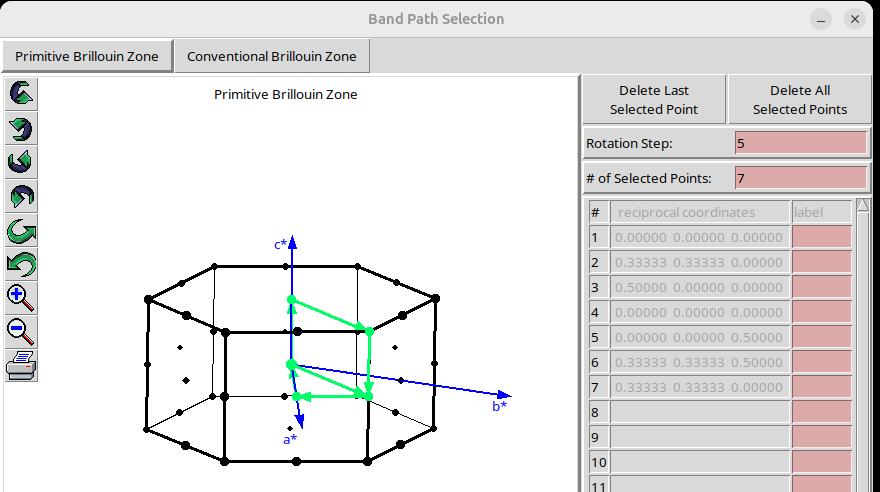 |

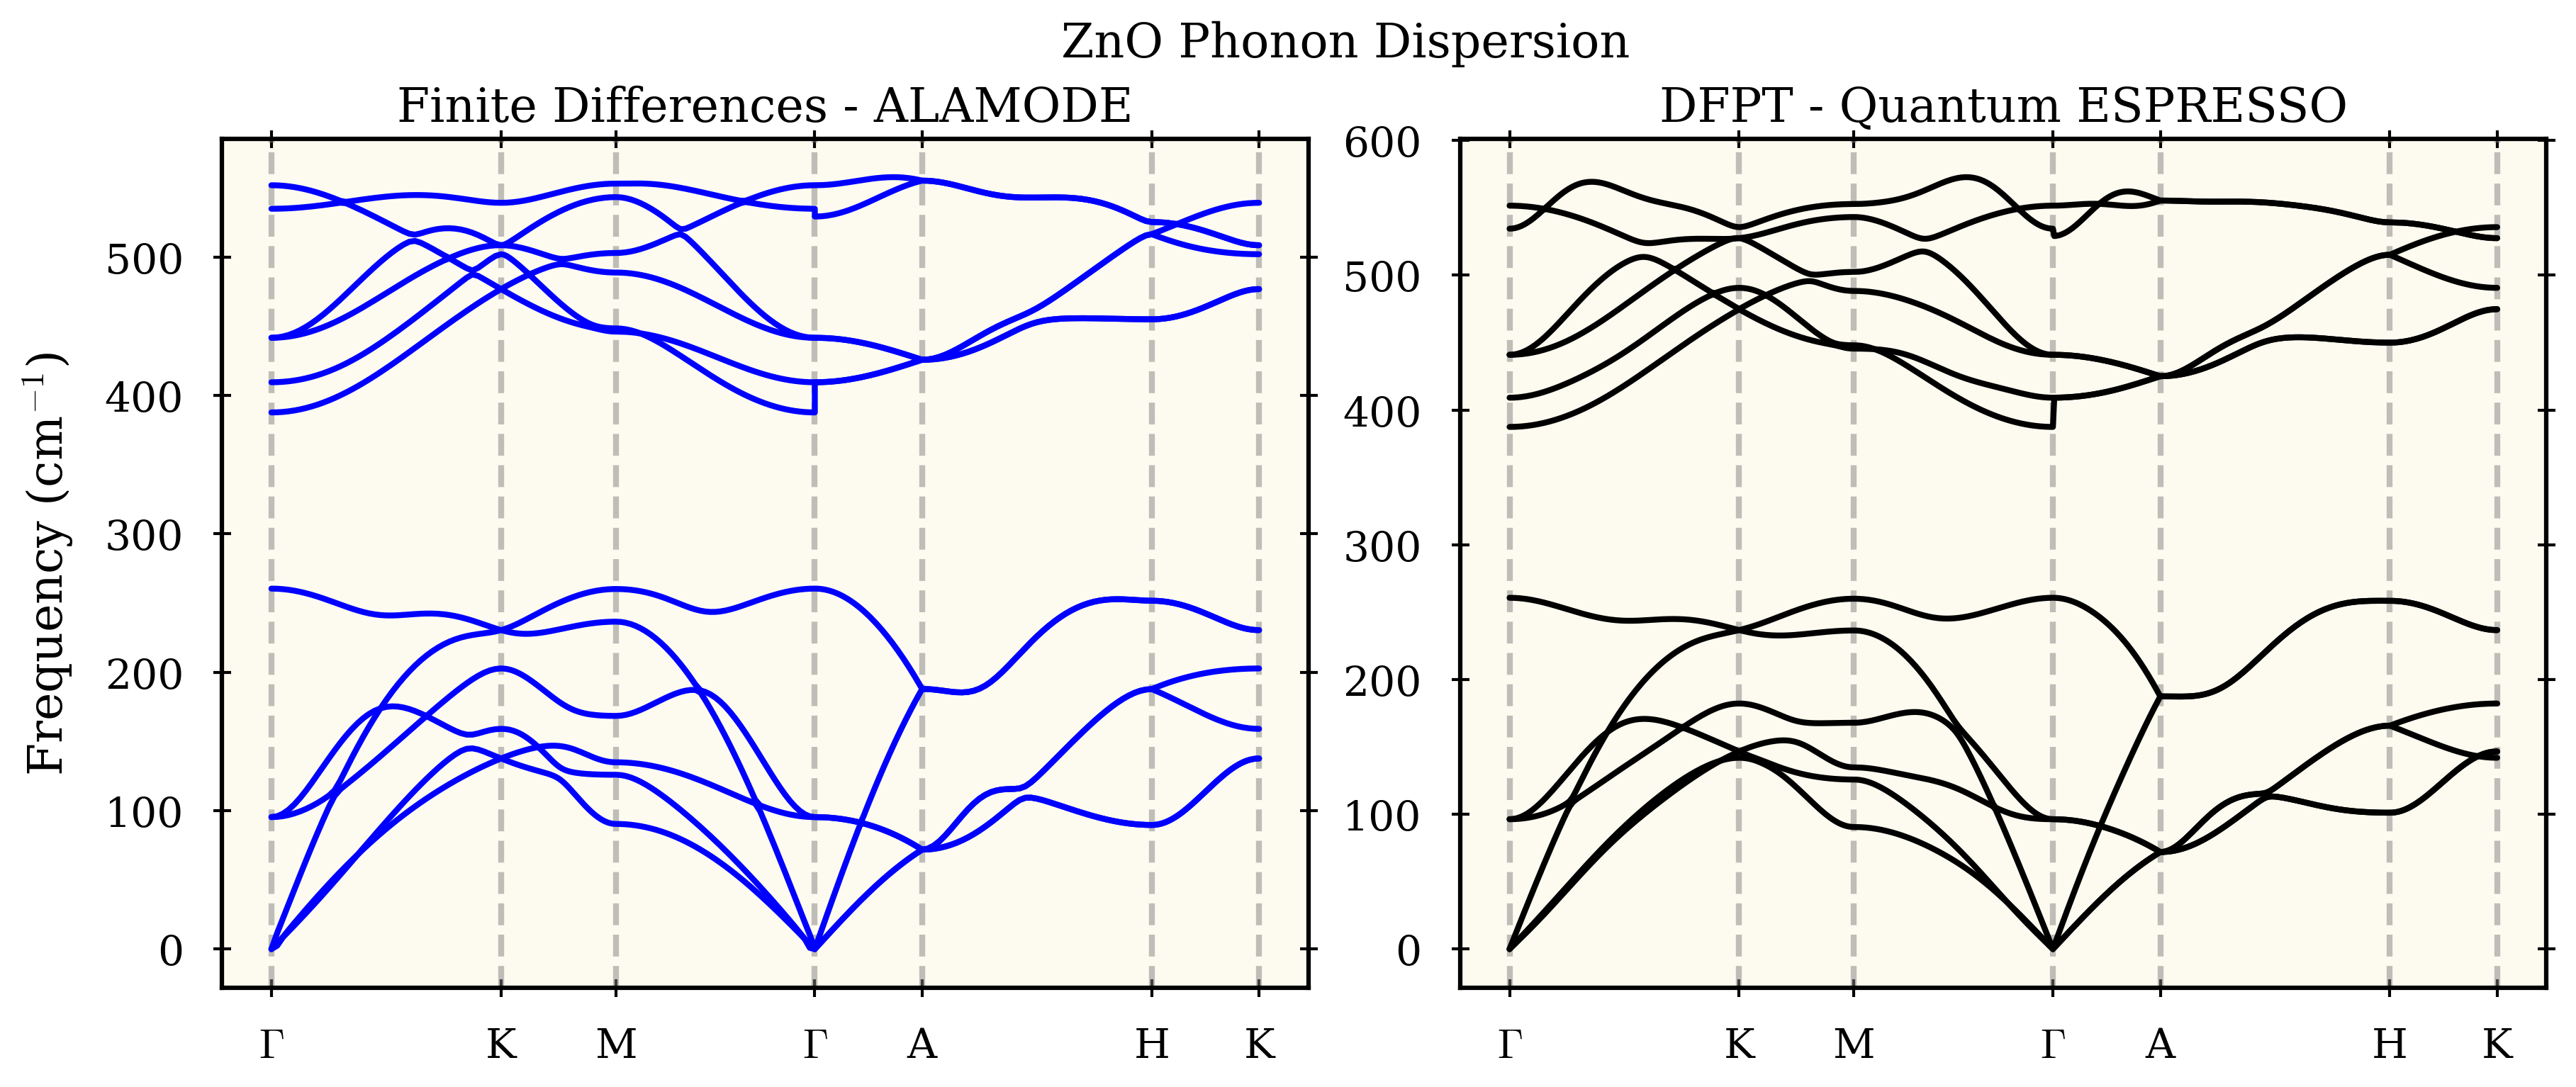

In [191]:
with plt.style.context("../mpl_themes/jvc.mplstyle"):
    fig, (ax1, ax2) = plt.subplots(
        ncols=2, figsize=(12, 5), layout="constrained", dpi=300
    )
    fig.suptitle("ZnO Phonon Dispersion", size=16, x=0.5225)

    for ax in (ax1, ax2):
        ax.tick_params(axis="both", which="minor", length=0)
        ax.tick_params(direction="inout")
        ax.set_yticks([0, 100, 200, 300, 400, 500, 600])
    # ---
    # ALAMODE
    ax1.set_title("Finite Differences - ALAMODE")
    ax1.set_ylabel(r"Frequency (cm$^{-1}$)")
    alamode_bands = "../alamode_phonons/qe_finite_diff/zno222NA3_GKMGAHK.bands"
    ph_data = get_alamode_phband(alamode_bands=alamode_bands)
    q = ph_data[:, 0]
    freq = ph_data[:, 1:]  # cm^-1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xlabels)
    xticks, xlabels = get_brillouin(alamode_bands)
    plot_sym_lines(ax1, xticks)
    for i in range(freq.shape[1]):
        if i == (freq.shape[1] - 1):
            ax1.plot(q, freq[:, i], color="blue", label="alamode")
        else:
            ax1.plot(q, freq[:, i], color="blue")

    # ---
    # Quantum ESPRESSO

    ax2.set_title("DFPT - Quantum ESPRESSO")
    qe_band = r"/home/jvc/ZnO_database/DFT_LDA/02_phonon_DFPT/ZnO_80.freq.gp"
    N_INTERPOLATION = 80
    qe_data = np.loadtxt(qe_band)
    q = qe_data[:, 0]
    freq = qe_data[:, 1:]
    high_symmetry_labels = [r"$\Gamma$", "K", "M", r"$\Gamma$", "A", "H", "K"]
    high_symmetry_points = [q[N_INTERPOLATION * i] for i in range(len(high_symmetry_labels))]

    ax2.set_xticks(high_symmetry_points)
    ax2.set_xticklabels(high_symmetry_labels)
    plot_sym_lines(ax=ax2, x_coords=high_symmetry_points)

    for i in range(freq.shape[1]):
        if i == (freq.shape[1] - 1):
            ax2.plot(q, freq[:, i], color="black", label="DFPT")
        else:
            ax2.plot(q, freq[:, i], color="black")

    plt.show()